# ETF relative momentum

**Not selected for implementaton**

The question we seek to answer is, can ranking shares by their past returns improve performance compared with holding the same eligible universe with equal weights?

Annually selected momentum strategy returns £17,254.97 from £10,000 over 01/2024-08/2026, compared with £12,766.26 for its equal weight, rebalanced monthly, benchmark. However, near enough all of the net profit comes from gold, volatility is increased substantially, and its mean daily net excess does not pass a 5% significance test.

This notebook contains the key facts, whilst the [original notebook](archive/etf_relative_momentum_research_2026-09-24.ipynb) keeps all the finer details

### Imports

In [39]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    candidate = parent / "uk_portfolio" / "etf_relative_momentum"
    if (candidate / "data/candidate_universe_v2.csv").is_file():
        PROJECT_DIR = candidate
        break
else:
    raise FileNotFoundError("Run this notebook within the trading_portfolio repository.")

for directory in (PROJECT_DIR / "src", PROJECT_DIR.parent / "etf_trend/src", PROJECT_DIR.parent / "equity_momentum/src"):
    if str(directory) not in sys.path:
        sys.path.insert(0, str(directory))

import etf_momentum_research as research
import etf_plotting

PROTOCOL = research.study_protocol()
INITIAL_CAPITAL = PROTOCOL["backtest"]["initial_capital_gbp"]
METRICS = ["final_value_gbp", "cagr_pct", "annualised_vol_pct", "sharpe_zero_rf", "max_drawdown_pct", "total_cost_gbp"]

## Data and universe

The used universe contains 20 GBP/GBX listings from the Trading 212 catalogue. They were chosen to broaden our exposure to different economic markets, and avoid FX and SDRT fees. It is a current universe, and hence experiences survivorship bias.

Load the frozen  yfinance raw/repaired daily histories, aligning to LSE schedule from 2015 onwards. Gaps remain missing and are not covered in, and survivorship bias remains. Adjusted closes provide the signals, with adjusted opening and closing prices giving the return proxy for the portfolio. Dividends are already embedded in the prices, so aren't credited again.

Reviewed IJPN, WLDS and CMOP observations on 24 October 2025 are excluded. The prior close supplies that day's valuation only.  Daily risk measurements around these marks remain estimates. It is not a rebalance or signal date, so calculations remain unchanged.

In [40]:
data = research.prepare_cached_data(PROJECT_DIR, PROTOCOL)
display(data["universe"][["research_exposure", "api_currency"]].join(data["audit"][["price_start", "missing_sessions", "excluded_quotes", "other_invalid_rows"]]))
print("Instruments:", len(data["universe"]))
print("Reviewed valuation marks:", int(data["stale_marks"].to_numpy().sum()))

,research_exposure,api_currency,price_start,missing_sessions,excluded_quotes,other_invalid_rows
ticker,,,,,,
IUSA,US large-cap equities,GBX,2015-01-02,0,0,0
ISF,UK large-cap equities,GBX,2015-01-02,0,0,0
IEUX,Europe ex-UK equities,GBX,2015-01-02,0,0,0
IJPN,Japanese equities,GBX,2015-01-02,0,1,0
IEEM,Emerging-market equities,GBX,2015-01-02,0,0,0
CPJ1,Developed Pacific ex-Japan equities,GBX,2015-01-02,0,0,0
MIDD,UK mid-cap equities,GBX,2015-01-02,0,0,0
WLDS,Developed-world small-cap equities,GBP,2018-04-04,0,1,0
IGLS,UK gilts: 0-5 years,GBP,2015-01-02,0,0,0


Instruments: 20
Reviewed valuation marks: 3


## Strategy and development


A the end of each month's final close, calculate adjusted returns over the lookback months. Rank all eligible assets by this, select the top N of them, and assign equal target weights. Complete the rebalance at the following open, while allowing weights to drift between rebalances. This is a relative momentum approach and winners can have negative returns. There is not a cash filter when returns are negative.

Original baseline used 12 month lookbacks and top 3 assets. Parameter sweep involved 3, 6, 9, 12 month lookbacks, with 1, 3, 5, 8 selected assets. If equal scores, the tie breaker is alphabetical order.

Each evaluation begins with £10,000. Fractional units are allowed, with no leverage, shorting, cash interest or forced final liquidation. Portfolio continuity across year boundaries. Model transaction fees using 10bp costs each side on net traded assets, including entry. 

Primary benchmark rebalances monthly to equal weights across all eligible assets in the universe, while paying proportional transaction fees. Context benchmark buys at equal weights, and allows weight to drift without rebalancing.

Use 2015 for warm-up. Evaluate baseline and 16 distinct fixed configurations from 02/2016-2021.

In [41]:
candidates = research.run_candidate_history(data, PROTOCOL)
development = research.development_analysis(data, candidates, PROTOCOL)
print("Configurations:", len(candidates["parameter_grid"]))
display(development["metrics"][METRICS].rename(index=research.LABELS).round(2))

Configurations: 16


,final_value_gbp,cagr_pct,annualised_vol_pct,sharpe_zero_rf,max_drawdown_pct,total_cost_gbp
portfolio,,,,,,
Original baseline,14152.64,6.05,12.80,0.52,-16.22,490.17
Monthly equal weight,15743.03,7.97,7.94,1.00,-18.07,33.57
Buy and hold,15973.30,8.24,8.55,0.96,-18.38,9.99


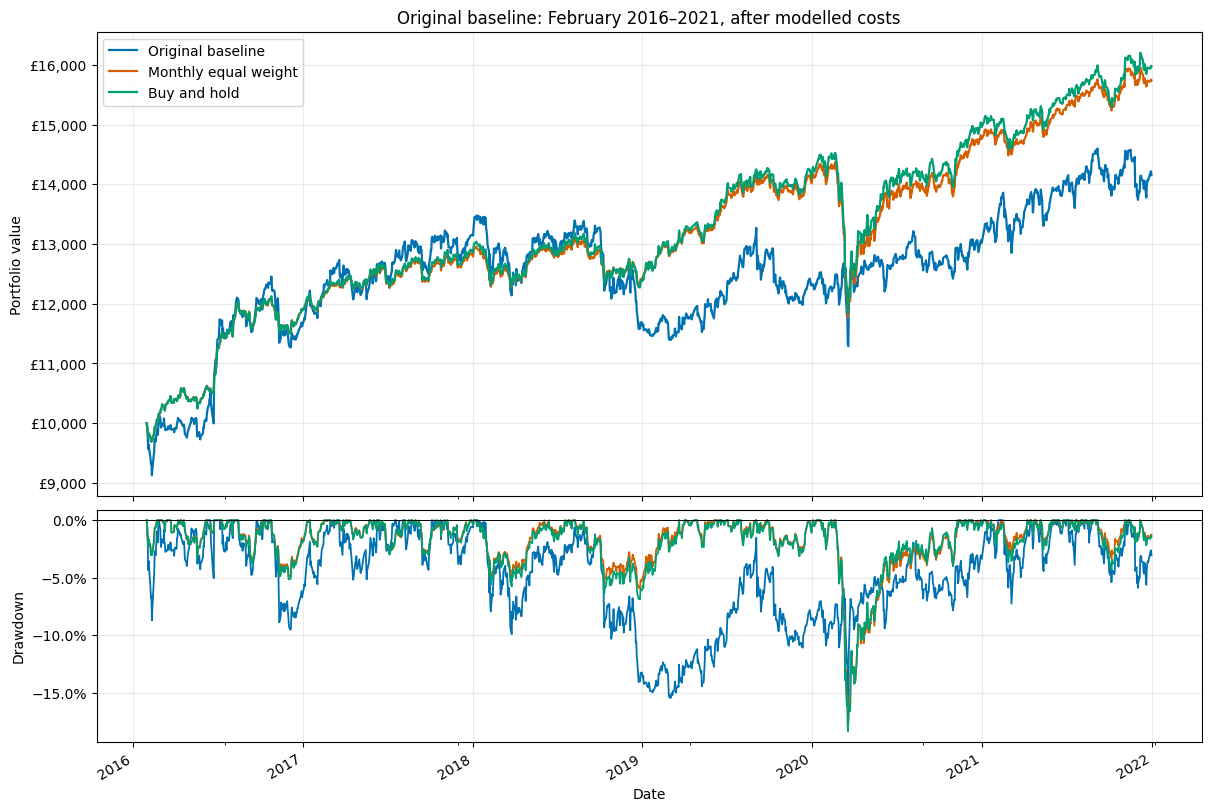

(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: title={'center': 'Original baseline: February 2016–2021, after modelled costs'}, xlabel='Date', ylabel='Portfolio value'>,
        <Axes: xlabel='Date', ylabel='Drawdown'>], dtype=object))

In [ ]:
baseline_equity = pd.DataFrame({
    name: result["daily"]["nav_close"]
    for name, result in development["backtests"].items()
}).rename(columns=research.LABELS)

etf_plotting.plot_equity_and_drawdown(baseline_equity, initial_capital_gbp=INITIAL_CAPITAL,
    start_date=baseline_equity.index[0] - pd.Timedelta(days=1),
    title="Original baseline: February 2016–2021, after modelled costs")

### Parameter sweep

Test mean daily strategy return minus the monthly benchmark return, after costs on both sides. Use a paired circular block bootstrap with 10,000 resamples, 63-session blocks, 95% basic intervals and a one-sided null of zero or negative mean excess. Apply Holm correction across the 16 configurations. The confidence intervals are pointwise, not simultaneous.

No configuration passes at 5%, even before correction. The baseline ends below both benchmarks, and no swept configuration has a higher development Sharpe ratio than the monthly benchmark. A hindsight winner is not a deployable selection rule.

In [43]:
sweep_table = development["sweep_metrics"][["lookback_months", "top_n", "cagr_pct", "sharpe_zero_rf", "max_drawdown_pct"]].join(development["sweep_tests"])
display(sweep_table.round(4))
print("Holm rejections at 5%:", int(sweep_table["reject_holm"].sum()))

,lookback_months,top_n,cagr_pct,sharpe_zero_rf,max_drawdown_pct,mean_daily_net_excess_bps,lower_ci_bps,upper_ci_bps,p_one_sided,p_holm,reject_holm
configuration_id,,,,,,,,,,,
0,3,1,7.0321,0.5220,-18.2051,-0.0157,-3.1281,3.3042,0.5066,1.0,False
1,3,3,3.4840,0.3440,-26.5822,-1.5168,-3.7884,0.8247,0.8989,1.0,False
2,3,5,5.8231,0.5839,-15.2012,-0.6960,-2.8351,1.3509,0.7367,1.0,False
3,3,8,7.6894,0.8387,-12.1896,-0.0569,-1.7315,1.5392,0.5172,1.0,False
4,6,1,-2.7452,-0.0609,-57.6692,-3.5961,-7.8871,1.2611,0.9286,1.0,False
5,6,3,4.9244,0.4373,-38.5744,-0.9304,-3.3672,1.5151,0.7755,1.0,False
6,6,5,6.7466,0.6447,-28.3083,-0.3354,-2.2376,1.5952,0.6343,1.0,False
7,6,8,7.0167,0.7710,-21.6477,-0.3041,-1.9374,1.3021,0.6409,1.0,False
8,9,1,3.7622,0.3151,-21.9459,-1.2226,-5.3465,2.7111,0.7183,1.0,False


Holm rejections at 5%: 0


## Annual walk-forward selection

Each January, Select specific configuration annually using the three preceding calendar years, selecting by net Sharpe. First window is 2017-2019, which gives the 2020-2021 testing configuration.

Evaluate 2020–2021 as a development period, 2022–2023 as validation, and 01/2024–08/2026 as the final evaluation. Each period starts afresh with £10,000, not a continuous investment. Evaluation years are used as training data for subsequent years.

In [44]:
evaluations = research.evaluate_all_periods(data, candidates, PROTOCOL)
annual_choices = pd.concat({period: result["choices"] for period, result in evaluations.items()}, names=["period", "fold"])
display(annual_choices[["train_start", "train_end", "test_start", "test_end",
    "configuration_id", "lookback_months", "top_n", "training_sharpe"]].round(3))

train_start  train_end test_start   test_end  \
period           fold                                                
development      0     2017-01-03 2019-12-31 2020-01-02 2020-12-31   
                 1     2018-01-02 2020-12-31 2021-01-04 2021-12-31   
validation       2     2019-01-02 2021-12-31 2022-01-04 2022-12-30   
                 3     2020-01-02 2022-12-30 2023-01-03 2023-12-29   
final_evaluation 4     2021-01-04 2023-12-29 2024-01-02 2024-12-31   
                 5     2022-01-04 2024-12-31 2025-01-02 2025-12-31   
                 6     2023-01-03 2025-12-31 2026-01-02 2026-08-28   

                       configuration_id  lookback_months  top_n  \
period           fold                                             
development      0                    0                3      1   
                 1                    0                3      1   
validation       2                    3                3      8   
                 3                    9                9      3   
final_evaluation 4                   14               12      5   
                 5                    8                9      1   
                 6                    8                9      1   

                       training_sharpe  
period           fold                   
development      0               0.571  
                 1               0.556  
validation       2               0.987  
                 3               0.660  
final_evaluation 4               0.625  
                 5               0.648  
                 6               1.462

In [ ]:
period_metrics = pd.concat({period: result["metrics"][METRICS] for period, result in evaluations.items()}, names=["period", "portfolio"])
display(period_metrics.rename(index=research.LABELS, level="portfolio").round(2))

final_value_gbp  cagr_pct  \
period           portfolio                                         
development      Walk-forward                 10731.47      3.60   
                 Monthly equal weight         11196.99      5.82   
                 Buy and hold                 11250.21      6.07   
validation       Walk-forward                  8982.83     -5.26   
                 Monthly equal weight          9441.48     -2.85   
                 Buy and hold                  9477.51     -2.67   
final_evaluation Walk-forward                 17254.97     22.80   
                 Monthly equal weight         12766.26      9.63   
                 Buy and hold                 12953.53     10.23   

                                       annualised_vol_pct  sharpe_zero_rf  \
period           portfolio                                                  
development      Walk-forward                       16.86            0.29   
                 Monthly equal weight                9.97            0.61   
                 Buy and hold                        9.79            0.65   
validation       Walk-forward                       10.50           -0.46   
                 Monthly equal weight                8.16           -0.31   
                 Buy and hold                        7.87           -0.30   
final_evaluation Walk-forward                       18.76            1.18   
                 Monthly equal weight                6.58            1.42   
                 Buy and hold                        6.86            1.45   

                                       max_drawdown_pct  total_cost_gbp  
period           portfolio                                               
development      Walk-forward                    -16.19          347.63  
                 Monthly equal weight            -18.07           16.19  
                 Buy and hold                    -17.60            9.99  
validation       Walk-forward                    -15.76          148.93  
                 Monthly equal weight            -15.87           14.52  
                 Buy and hold                    -14.65            9.99  
final_evaluation Walk-forward                    -26.06          178.84  
                 Monthly equal weight             -8.24           16.32  
                 Buy and hold                     -8.31            9.99

### Development walk-forward: 2020–2021

Our approach loses the lead it holds early in the development period near the end of 2021. It finishes at £10,731, versus £11,197 for the monthly benchmark.

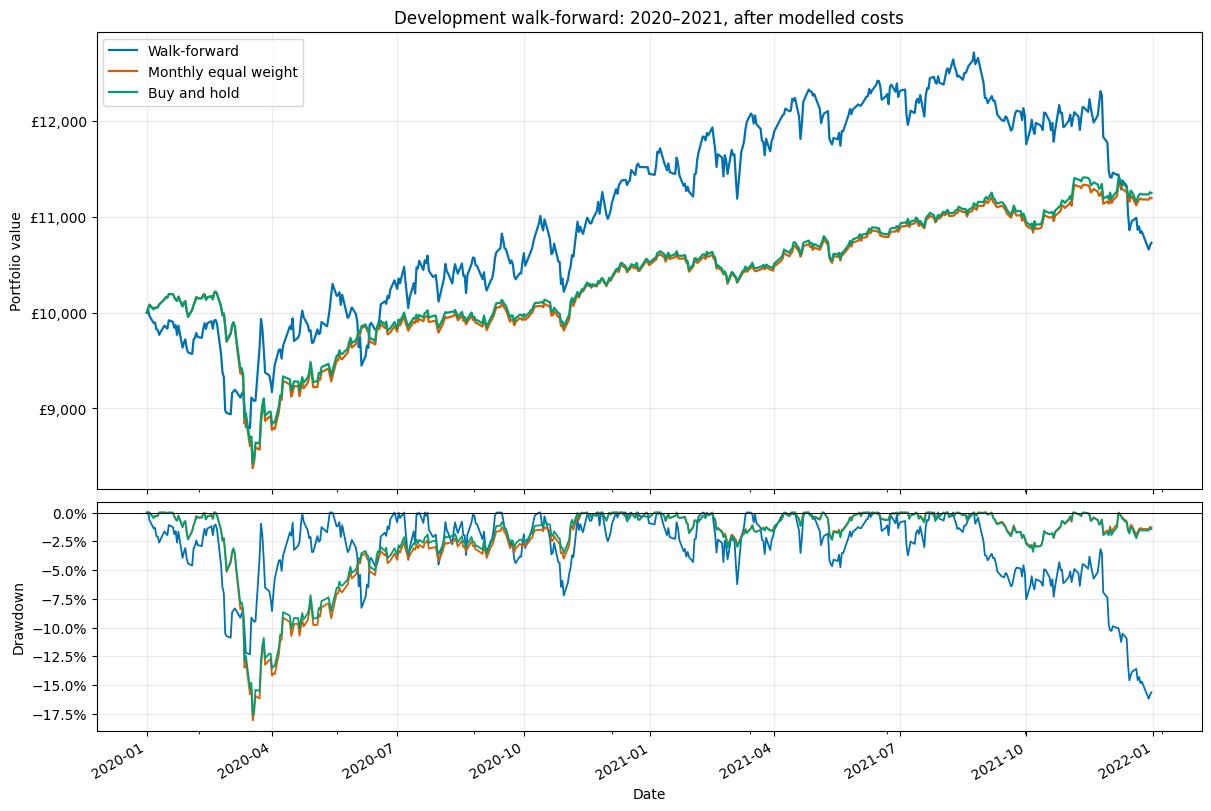

(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: title={'center': 'Development walk-forward: 2020–2021, after modelled costs'}, xlabel='Date', ylabel='Portfolio value'>,
        <Axes: xlabel='Date', ylabel='Drawdown'>], dtype=object))

In [ ]:
result = evaluations["development"]
etf_plotting.plot_equity_and_drawdown(result["equity"].rename(columns=research.LABELS), initial_capital_gbp=INITIAL_CAPITAL, start_date=result["equity"].index[0] - pd.Timedelta(days=1),
    title="Development walk-forward: 2020–2021, after modelled costs")

### Validation: 2022–2023

All three portfolios lose money. Walk-forward momentum returns -10.17%, compared with -5.59% for monthly equal weight, so our approach underperforms again. Its volatility is also higher.

,Walk-forward,Monthly equal weight,Buy and hold
year,,,
2022,-10.07,-11.10,-10.45
2023,-0.12,6.21,5.84


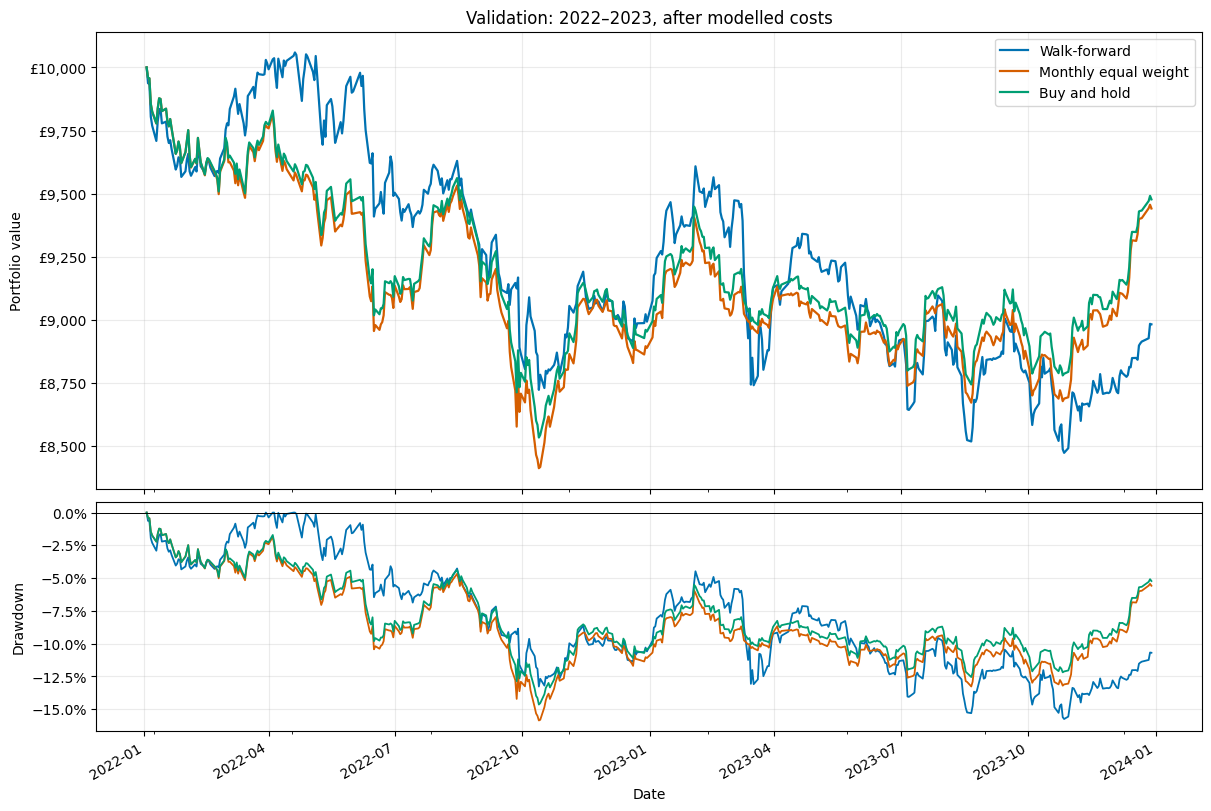

(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: title={'center': 'Validation: 2022–2023, after modelled costs'}, xlabel='Date', ylabel='Portfolio value'>,
        <Axes: xlabel='Date', ylabel='Drawdown'>], dtype=object))

In [47]:
result = evaluations["validation"]
display(result["annual_returns"].rename(columns=research.LABELS).round(2))
etf_plotting.plot_equity_and_drawdown(result["equity"].rename(columns=research.LABELS),
    initial_capital_gbp=INITIAL_CAPITAL,
    start_date=result["equity"].index[0] - pd.Timedelta(days=1),
    title="Validation: 2022–2023, after modelled costs")

### Final evaluation: January 2024–August 2026

The strategy ends at £17,255, compared with £12,766 for monthly equal weight. This comes with 18.76% annualised volatility and a 26.06% maximum drawdown, versus 6.58% and 8.24% for the benchmark, although it comes with greater volatility, worse drawdown, and a lower Sharpe when compared with both both benchmarks. Drawdown includes the original £10,000 starting capital when finding running peaks.

,Walk-forward,Monthly equal weight,Buy and hold
year,,,
2024,10.84,5.40,5.47
2025,52.38,12.20,13.16
2026,2.16,7.96,8.53


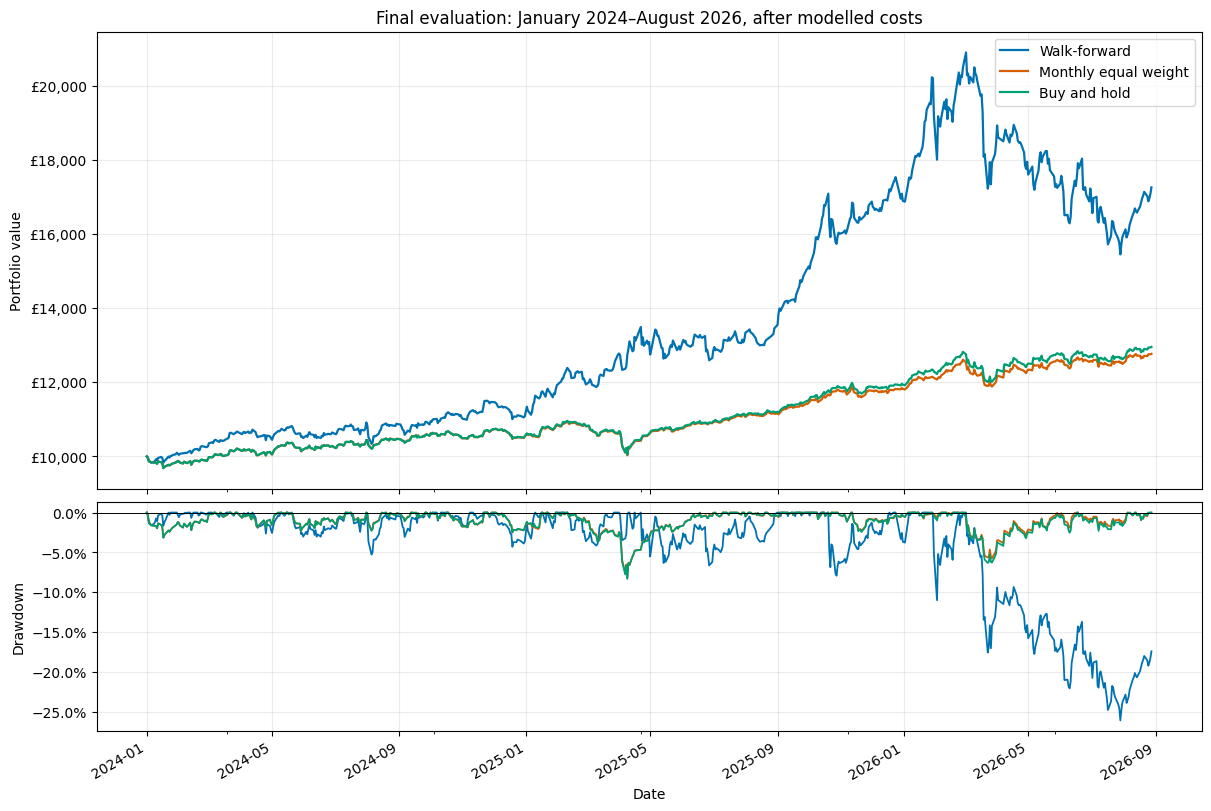

In [ ]:
final = evaluations["final_evaluation"]
display(final["annual_returns"].rename(columns=research.LABELS).round(2))

figure, _ = etf_plotting.plot_equity_and_drawdown(final["equity"].rename(columns=research.LABELS), initial_capital_gbp=INITIAL_CAPITAL,
    start_date=final["equity"].index[0] - pd.Timedelta(days=1), title="Final evaluation: January 2024–August 2026, after modelled costs")

(PROJECT_DIR / "figures").mkdir(exist_ok=True)
figure.savefig(PROJECT_DIR / "figures/final_equity_drawdown.png", dpi=160)

### Where the profit came from

Gold contributes £7,224.43 of the final strategy's £7,254.97 net profit, or 99.58%, with the strategy targeting 100% gold throughout all of 2025 and the first 4 months of 2026. Other assets profits and losses effectively cancel. The strategy managed to identify a sustained winner, but this does not establish repeatable success across different exposure areas

In [49]:
attribution, daily_asset_net_pnl = research.attribute_profit(final["backtests"]["walk_forward"], PROTOCOL["backtest"])
attribution_table = attribution.join(data["universe"]["research_exposure"])
display(attribution_table.loc[attribution_table[["gross_pnl_gbp", "cost_gbp"]].abs().sum(axis=1).gt(1e-8)].sort_values("net_pnl_gbp", ascending=False).round(2))
gold_targets = final["targets"]["SGLN"]
gold_allocations = pd.DataFrame({
    "monthly_allocations": gold_targets.groupby(gold_targets.index.year).size(),
    "months_holding_gold": gold_targets.gt(0).groupby(gold_targets.index.year).sum(),
    "maximum_gold_target_pct": 100 * gold_targets.groupby(gold_targets.index.year).max()
})
display(gold_allocations)
print("Gold share of net profit: {:.2%}".format(attribution.loc["SGLN", "net_pnl_gbp"] / attribution["net_pnl_gbp"].sum()))

,gross_pnl_gbp,cost_gbp,net_pnl_gbp,research_exposure
ticker,,,,
SGLN,7253.80,29.37,7224.43,Physical gold
CMOP,853.15,51.25,801.90,Broad commodity futures
IUSA,521.48,4.69,516.79,US large-cap equities
IJPN,173.47,4.49,168.98,Japanese equities
MIDD,63.75,4.59,59.15,UK mid-cap equities
IEUX,49.11,8.33,40.79,Europe ex-UK equities
GHYS,2.27,4.12,-1.85,"Global high-yield corporate bonds, GBP hedged"
WLDS,6.20,12.78,-6.58,Developed-world small-cap equities
ISF,-3.43,4.33,-7.76,UK large-cap equities


,monthly_allocations,months_holding_gold,maximum_gold_target_pct
Date,,,
2024,12,10,20.0
2025,12,12,100.0
2026,8,4,100.0


Gold share of net profit: 99.58%


### Final excess-return test

Apply the same 63 trading day block bootstrap to the walk-forward strategy's daily net excess compared with monthly equal weight.Since there is only one adaptive strategy in this period, the Holm adjusted value is the same as the standard p-value.

The mean is +5.088bp per day, with a 95% interval of [-2.420, +13.093]bp and a one-sided p-value of 0.0943. The null is not rejected at 5%. Failure to reject does not meant that no edge exists.

In [50]:
final_test = research.test_final_excess(final, PROTOCOL)
display(final_test.round(4))

,mean_daily_net_excess_bps,lower_ci_bps,upper_ci_bps,p_one_sided,p_holm,reject_holm
strategy,,,,,,
walk_forward,5.0877,-2.4205,13.0929,0.0943,0.0943,False


## Conclusion and retained outputs

The evidence above does not support implementing this strategy in action. The strategy performs poorly in development and the earlier evaluation period, and even though the final period performed well, it depends almost entirely on gold, and carries noticeably more risk. Whether these net returns add value alongside other strategies remains untested.